In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv("C:\\Users\\FCAFR\\OneDrive\\B_Documentos\\Conhecimento\\CAIXAVerso\\2026\\Tecnicas_de_programacao\\Projeto_final\\Projeto_Caixa_verso\\Repositorio_Projeto_Caixaverso\\dados\\KaggleV2-May-2016.csv")

In [58]:
df.shape
df.info()
df.memory_usage(deep=True)

<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 17.6 MB


Index                 132
PatientId          884216
AppointmentID      884216
Gender             994743
ScheduledDay      3094756
AppointmentDay    3094756
Age                884216
Neighbourhood     2158977
Scholarship        884216
Hipertension       884216
Diabetes           884216
Alcoholism         884216
Handcap            884216
SMS_received       884216
No-show           1127589
dtype: int64

In [59]:
df.sample(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
101608,7.431650e+13,5722608,M,2016-05-20T07:28:33Z,2016-06-02T00:00:00Z,82,PARQUE MOSCOSO,0,0,0,0,0,0,No
92335,7.715732e+12,5781386,F,2016-06-07T09:24:54Z,2016-06-07T00:00:00Z,35,SANTA MARTHA,0,0,0,0,0,0,No
73222,7.351960e+14,5637870,M,2016-04-29T07:28:14Z,2016-05-06T00:00:00Z,16,ROMÃO,0,0,0,0,0,1,No
5876,2.338834e+12,5660401,M,2016-05-04T16:25:08Z,2016-05-04T00:00:00Z,16,FORTE SÃO JOÃO,0,0,0,0,0,0,No
10708,9.557127e+13,5664545,F,2016-05-05T12:47:52Z,2016-05-05T00:00:00Z,37,MÁRIO CYPRESTE,0,1,0,0,0,0,No


In [60]:
faltantes = df.isnull().sum()
faltantes_percentual = (faltantes / len(df)) * 100
print("Valores faltantes por coluna, em %:" , faltantes_percentual)

Valores faltantes por coluna, em %: PatientId         0.0
AppointmentID     0.0
Gender            0.0
ScheduledDay      0.0
AppointmentDay    0.0
Age               0.0
Neighbourhood     0.0
Scholarship       0.0
Hipertension      0.0
Diabetes          0.0
Alcoholism        0.0
Handcap           0.0
SMS_received      0.0
No-show           0.0
dtype: float64


In [61]:
duplicadas = df.duplicated().sum()
duplicadas_percentual = (duplicadas / len(df)) * 100
print("Valores duplicados, em %:" , duplicadas_percentual)

Valores duplicados, em %: 0.0


Verifica-se que não há elementos faltantes, nem duplicadas.

Passaremos a realizar a padronização nas strings:

In [62]:
# Padronizando a coluna 'gender', removendo espaços em branco e convertendo para letras maiúsculas
df["Gender"] = df["Gender"].str.upper().str.strip() 

# Padronizando a coluna 'No-show', convertendo para letras maiúsculas e mapeando 'NO' para 0 e 'YES' para 1
df["No-show"] = df["No-show"].str.upper().map({'NO': 0, 'YES': 1})  # Mantendo apenas 'NO' e 'YES'

In [63]:
df[["Gender", "No-show"]].head(5)

,Gender,No-show
0,F,0
1,M,0
2,F,0
3,F,0
4,F,0


In [64]:
# Verificando valores inválidos na coluna 'Age':
df[df['Age'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,0


In [65]:
# Por se tratar de apenas um registro, vamos removê-lo do dataset.
df = df[df['Age'] >= 0]

In [66]:
# Padronizaçao da coluna 'Schoolarship' para inteiros, convertendo valores nulos para 0:
df['Scholarship'] = df['Scholarship'].fillna(0).astype(int)

Tratamento de outliers com o método IQR:

In [67]:
df['dias_espera'] = (pd.to_datetime(df['ScheduledDay']) - pd.to_datetime(df['AppointmentDay'])).dt.days
df['dias_espera'] = df['dias_espera'].abs()  # Garantindo que os valores sejam positivos
df['dias_espera'].sample(5) # Conferindo se a coluna foi criada corretamente

9821       4
25886     15
107405     0
30903     18
90899      7
Name: dias_espera, dtype: int64

In [68]:
# Definindo os limites para identificar outliers na coluna 'dias_espera' usando o método do IQR:
Q1 = df['dias_espera'].quantile(0.25)
Q3 = df['dias_espera'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

In [69]:
df['dias_espera_outlier'] = np.where((df['dias_espera'] < limite_inferior) | (df['dias_espera'] > limite_superior), 1, 0)
df['dias_espera_outlier'].value_counts(normalize=True) * 100   

dias_espera_outlier
0    94.749652
1     5.250348
Name: proportion, dtype: float64

Decisão:

Remover apenas valores impossíveis (ex.: espera de 300 dias).

Manter esperas longas plausíveis, pois podem explicar faltas.

In [71]:
# Imputando valores faltantes na coluna 'Age' com a mediana da idade por bairro, 
# para preservar a distribuição da idade em cada bairro. 
# Isso é feito usando o método `transform` do pandas, que permite aplicar uma função a cada grupo de dados.:
df['Age'] = df.groupby('Neighbourhood')['Age'].transform(lambda x: x.fillna(x.median()))


Tratamento dos dados e criação de variáveis para análise exploratória:

In [72]:
# Criando coluna com as faixas etárias para análise:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 35, 50, 65, 100], labels=['0-17', '18-34', '35-49', '50-64', '65+'])

In [73]:
# Criando coluna 'Comorbidade':
comorbidades = ['Diabetes', 'Alcoholism', 'Hipertension', 'Handcap']
df['num_comorbidades'] = df[comorbidades].sum(axis=1)
df['multiplas_comorbidades'] = np.where(df['num_comorbidades'] > 1, 1, 0)
df.sample(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,dias_espera,dias_espera_outlier,Age_Group,num_comorbidades,multiplas_comorbidades
87266,1.359813e+14,5659330,F,2016-05-04T13:38:25Z,2016-06-08T00:00:00Z,21,SANTA MARTHA,0,0,0,0,0,1,0,35,0,18-34,0,0
102440,7.764681e+12,5768735,F,2016-06-03T07:57:34Z,2016-06-03T00:00:00Z,20,FORTE SÃO JOÃO,0,0,0,0,0,0,0,0,0,18-34,0,0
82884,4.363545e+13,5703210,F,2016-05-16T13:38:36Z,2016-05-16T00:00:00Z,38,ITARARÉ,0,0,0,0,0,0,0,0,0,35-49,0,0
83458,5.239758e+14,5720299,F,2016-05-19T13:38:11Z,2016-05-24T00:00:00Z,23,BONFIM,0,0,0,0,0,1,1,5,0,18-34,0,0
21513,6.897679e+12,5676929,M,2016-05-09T16:54:04Z,2016-05-11T00:00:00Z,72,CONSOLAÇÃO,0,1,0,1,0,0,0,2,0,65+,2,1


Questionando os Dados:

In [74]:
# Analisando a taxa de não comparecimento por faixa etária:
df.groupby('Age_Group')['No-show'].agg(['mean', 'count'])
pesos = df.groupby('Age_Group')['No-show'].mean()
pesos_normalizados = pesos / pesos.mean()

In [75]:
# Criando uma tabela auxiliar com os dados de 'No-show' e probabilidade de não comparecimento por faixa etária:
tabela_risco = pd.DataFrame({
    'Age_Group': ['0-18', '18-34', '35-49', '50-64', '65+'],
    'peso_risco': [0.75, 0.92, 1.42, 1.13, 0.63] # Baseado nos pesos normalizados calculados anteriormente
})

In [76]:
# Fazendo merge da tabela de risco com o dataframe original para adicionar a coluna 'peso_risco' correspondente a cada faixa etária:
df = df.merge(tabela_risco, on='Age_Group', how='left')

In [77]:
df.sample(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,dias_espera,dias_espera_outlier,Age_Group,num_comorbidades,multiplas_comorbidades,peso_risco
21202,3.361445e+11,5640056,M,2016-04-29T10:03:34Z,2016-05-02T00:00:00Z,38,RESISTÊNCIA,0,0,0,0,0,1,1,3,0,35-49,0,0,1.42
68094,3.719953e+11,5585552,F,2016-04-14T17:01:51Z,2016-05-31T00:00:00Z,30,ANDORINHAS,0,0,0,0,0,0,1,47,1,18-34,0,0,0.92
19640,2.723732e+13,5655919,F,2016-05-04T07:23:09Z,2016-05-06T00:00:00Z,66,ILHA DO PRÍNCIPE,0,1,0,0,0,0,0,2,0,65+,1,0,0.63
63689,9.386199e+14,5660243,F,2016-05-04T15:53:13Z,2016-05-13T00:00:00Z,27,DA PENHA,0,0,0,0,0,0,0,9,0,18-34,0,0,0.92
17856,7.412735e+11,5660915,F,2016-05-05T07:02:12Z,2016-05-06T00:00:00Z,52,JARDIM DA PENHA,0,0,0,0,0,0,0,1,0,50-64,0,0,1.13


In [78]:
# Analisando a taxa de não comparecimento por faixa etária e comorbidades:
tabela_risco_idade = df.groupby('Age_Group')[['peso_risco', 'No-show']].mean()
tabela_risco_idade

,peso_risco,No-show
Age_Group,,
0-17,NaN,0.225372
18-34,0.92,0.238348
35-49,1.42,0.203258
50-64,1.13,0.165491
65+,0.63,0.155183


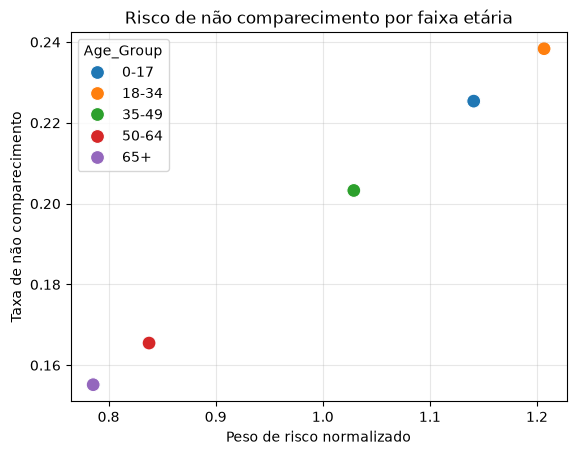

In [79]:
# Gráfico 
# Gráfico da taxa de não comparecimento por faixa etária
grafico_risco = pd.DataFrame({
    'Age_Group': pesos.index,
    'peso_risco': pesos_normalizados.values,
    'No-show': pesos.values
})

sns.scatterplot(
    data=grafico_risco,
    x='peso_risco',
    y='No-show',
    hue='Age_Group',
    s=100
)

plt.xlabel('Peso de risco normalizado')
plt.ylabel('Taxa de não comparecimento')
plt.title('Risco de não comparecimento por faixa etária')
plt.grid(alpha=0.3)
plt.show()

In [80]:
df.head(5)

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,dias_espera,dias_espera_outlier,Age_Group,num_comorbidades,multiplas_comorbidades,peso_risco
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,0,0,0,50-64,1,0,1.13
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,0,0,0,50-64,0,0,1.13
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,0,0,0,50-64,0,0,1.13
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,0,0,0-17,0,0,NaN
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,0,0,0,50-64,2,1,1.13


Elaboração de tabela pivot para verificar os efeitos do sms no comparecimento às consultas.
Descobrimos que o envio de sms esta associado a uma maior taxa de não comparecimento. Isso pode gerar uma conclusão errada, pois na verdade os sms são enviados a pacientes com históricos de faltas, com tempos de espera longos, de certos bairros e pacientes jovens (grupo que mais falta).
Importante destacar, então, que o SMS não causa a falta, mas é apenas um marcador de risco nesse caso.

In [84]:
pivot_table_sms = pd.pivot_table(df, values='No-show', index='SMS_received', columns='Age_Group', aggfunc='mean')
pivot_table_sms

Age_Group,0-17,18-34,35-49,50-64,65+
SMS_received,,,,,
0,0.187961,0.185085,0.166329,0.143625,0.136173
1,0.313427,0.339959,0.277975,0.208782,0.199400


Outras análises efetuadas que não resultaram em conclusões:

In [31]:
categorias = ['No-show', 'SMS_received', 'Alcoholism', 'Diabetes', 'Hipertension', 'Scholarship']
for v1, v2 in itertools.combinations(categorias, 2):
    crosstab = pd.crosstab(df[v1], df[v2])
    print(f"\nCrosstab between {v1} and {v2}:")
    print(crosstab)


Crosstab between No-show and SMS_received:
SMS_received      0      1
No-show                   
No            62510  25698
Yes           12535   9784

Crosstab between No-show and Alcoholism:
Alcoholism      0     1
No-show                
No          85525  2683
Yes         21642   677

Crosstab between No-show and Diabetes:
Diabetes      0     1
No-show              
No        81695  6513
Yes       20889  1430

Crosstab between No-show and Hipertension:
Hipertension      0      1
No-show                   
No            70179  18029
Yes           18547   3772

Crosstab between No-show and Scholarship:
Scholarship      0     1
No-show                 
No           79925  8283
Yes          19741  2578

Crosstab between SMS_received and Alcoholism:
Alcoholism        0     1
SMS_received             
0             72532  2513
1             34635   847

Crosstab between SMS_received and Diabetes:
Diabetes          0     1
SMS_received             
0             69458  5587
1            

In [33]:
def cramers_v(x, y):
    tabela = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabela)[0]
    n = tabela.sum().sum()
    r, k = tabela.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

categoricas = ['No-show', 'SMS_received', 'Alcoholism', 'Diabetes', 'Hipertension', 'Scholarship']

matriz = pd.DataFrame(index=categoricas, columns=categoricas)

for v1 in categoricas:
    for v2 in categoricas:
        matriz.loc[v1, v2] = cramers_v(df[v1], df[v2])

matriz = matriz.astype(float)
print(matriz)


               No-show  SMS_received  Alcoholism  Diabetes  Hipertension  \
No-show       0.999972      0.126407    0.000130  0.015136      0.035673   
SMS_received  0.126407      0.999979    0.026091  0.014513      0.006243   
Alcoholism    0.000130      0.026091    0.999847  0.018371      0.087905   
Diabetes      0.015136      0.014513    0.018371  0.999932      0.433042   
Hipertension  0.035673      0.006243    0.087905  0.433042      0.999971   
Scholarship   0.029097      0.001161    0.034934  0.024835      0.019691   

              Scholarship  
No-show          0.029097  
SMS_received     0.001161  
Alcoholism       0.034934  
Diabetes         0.024835  
Hipertension     0.019691  
Scholarship      0.999949  


>>>>> A maior associação do seu dataset: Diabetes × Hipertension = 0.433
Esse é o valor mais alto da matriz:

Código
Diabetes ↔ Hipertension = 0.433
Isso é uma associação moderada, e faz sentido clinicamente:
pessoas com diabetes frequentemente têm hipertensão.

Esse é o único par com associação realmente relevante.

>>>> Outras associações interessantes
Alcoholism × Hipertension = 0.0879
Fraca, mas existe — também faz sentido clinicamente.

SMS_received × qualquer outra variável
Tudo perto de zero → SMS_received é independente das comorbidades.

Scholarship × qualquer variável
Tudo muito baixo → praticamente independente.

